In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import WMAP9 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from astroquery.vizier import Vizier
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis, FastStepBasis
from prospect.models import priors
from prospect.models.sedmodel import SedModel
from prospect.utils.obsutils import fix_obs
from prospect.likelihood import lnlike_spec, lnlike_phot, write_log
from prospect.likelihood import chi_spec, chi_phot
import fsps
import sedpy.observate as observate
import prospect
import emcee
import dynesty

from prospect.models import priors, sedmodel
from prospect.sources import FastStepBasis
from sedpy import observate
from astropy.cosmology import WMAP9
from astropy.io import fits

from scipy.stats import truncnorm

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

bands = {
    # HST - Using common filters for ACS and WFC3
    'HST_F218W': ('F218W', 2225.17, 'UVIS', 'MAST'),
    'HST_F225W': ('F225W', 2371.15, 'UVIS', 'MAST'),
    'HST_F275W': ('F275W', 2709.29, 'UVIS', 'MAST'),
    'HST_F435W': ('F435W', 4329.85, 'ACS', 'MAST'),
    'HST_F606W': ('F606W', 5921.1, 'ACS', 'MAST'),
    'HST_F814W': ('F814W', 8057.2, 'ACS', 'MAST'),
    'HST_F125W': ('F125W', 12486.07, 'IR', 'MAST'),
    'HST_F160W': ('F160W', 15369.1, 'IR', 'MAST'),
    # Spitzer - Using channel names for IRAC and MIPS
    'Spitzer_I1_3.6': ('1', 36000., 'IRAC', 'Spitzer'),
    'Spitzer_I2_4.5': ('2', 45000., 'IRAC', 'Spitzer'),
    'Spitzer_I4_8.0': ('4', 80000., 'IRAC', 'Spitzer'),
    'Spitzer_M1_24': ('1', 240000., 'MIPS', 'Spitzer'),
}

test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

peas = ascii.read('photometry_results.csv')

lsun = 3.846e33
pc = 3.085677581467192e18  # in cm

lightspeed = 2.998e18  # AA/s
to_cgs = lsun/(4.0 * np.pi * (pc*10)**2)
jansky_mks = 1e-26

In [56]:
grapes = tab[(tab['halpha_flux']>0)&(tab['oiii5007_ew']>100)]
grapes.sort('oiii5007_flux')
grapes[-2]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d04m12pt825s-44d21m10pt642s,38.070229166666664,-44.35295611111111,0.40292640529351553,66.73403958150307,0,0,0,8.969458542722732,0.0071141320617926825,8.150940159413311,0.0002622770955946467,8.162632124545151,0.2310792637281556,52.167125686054774,11.366223970474508,0.282,rxj0232m44,22567.1412073046,354.6168687556022,128.08897740369298,5.497713979981577,5006.834015829306,1.9980823399660776,47.58586696794032,6909.889981192684,933.7871419981336,19.408720732766298,7.277460935748094,4958.849131583009,1.7838306402540278,42.122918614158394,9815.98386042128,333.47237723449535,31.03228480758622,5.3098464551879445,3726.2293091856905,2.2526145560741524,73.15631758124707,11807.609335391948,374.7664395449063,37.404139444223546,5.967367573421555,3729.12559

In [57]:
# fig, ax = pf.create_plot()
# axes = [ax]
candidate = grapes[-2]
cluster = candidate['name']
print(cluster)
loc = '../../../cubes/'+cluster+'_COMBINED_CUBE_MED_FINAL.fits'
with fits.open(loc) as hdul:
    cx,cy = (hdul[1].header['CRVAL1'],hdul[1].header['CRVAL2'])
    cent = SkyCoord(cx,cy, unit = u.deg)

galloc = SkyCoord(candidate['ra'], candidate['dec'], unit=u.deg)
cube_ift = ift.museCube(loc, cent.ra.deg,cent.dec.deg)
cluster = Cube(loc)
subcube = cluster.subcube((galloc.dec.deg,galloc.ra.deg), size=3)
linefits = cube_ift.pick_target(galloc,candidate['z'],0.7,plot=True)

spectrum_o = cube_ift.spectra.get(list(cube_ift.spectra.keys())[0])
spectrum_o = spectrum_o.rebin(20)
rest_spectrum0 = cube_ift.rest_spectra.get(list(cube_ift.rest_spectra.keys())[0])
rest_spectrum = rest_spectrum0.rebin(20)

freq = np.linspace(rest_spectrum.get_start(), rest_spectrum.get_end(), rest_spectrum.shape[0])
redshift = cube_ift.ex_table['z'][0]
d_lum = cosmo.luminosity_distance(redshift).to(u.Mpc).value 

wave_rest = spectrum_o.wave.coord()  # Angstroms
flux = rest_spectrum.data*1e-20            # erg/s/cm^2/Angstrom (check units)
flux_unc = np.sqrt(rest_spectrum.var*1e-20)   # Get std deviation from variance

c = speedoflight.to(u.AA / u.s).value

flux_nu = flux * (wave_rest**2 / c)
unc_nu = flux_unc * (wave_rest**2 / c)
flux_jy = flux_nu/1e-23
unc_jy = unc_nu/1e-23
mask = flux_jy>0

rxj0232m44


In [58]:
# plt.semilogx(wave_rest[mask],flux_jy[mask]*1000)
cand_phot = peas[peas['object_id']==candidate['object_id']]

filters_names = [stri[5:] for stri in list(cand_phot.keys()[3:])]
filters_cwav = np.array([bands.get(name)[1] for name in filters_names])
photometry = np.array(cand_phot[0][3:])
photometry[photometry == -999] = np.nan
# plt.scatter(filters_cwav,photometry/1e3)
vizier = Vizier()
query = vizier.query_region(galloc, radius=3*u.arcsecond)
des_table = query['II/357/des_dr1']


In [59]:
hst_filters = ['wfc3_uvis_f225w','wfc3_uvis_f275w','acs_wfc_f435w','acs_wfc_f606w','acs_wfc_f814w','wfc3_ir_f125w','wfc3_ir_f160w',]
hst_phot_ujy = photometry[1:-4]
spitzer_filters = ['spitzer_irac_ch'+n for n in ['1','2','4']]
spizter_phot_ujy = photometry[-4:-1]
des_filters =  ['decam_'+b for b in ['g','r','i','z','Y']]
des_phot_mag = np.array([des_table[b+'mag'].data for b in ['g','r','i','z','Y']]).squeeze(1)
des_phot_ujy = (3631*(10**(-0.4*des_phot_mag)))*1e6

In [60]:
def build_obs(**extras):
    obs = {}
    filternames = hst_filters + spitzer_filters + des_filters
    obs["filters"] = sedpy.observate.load_filters(filternames)
    obs["maggies"] = (np.concatenate([hst_phot_ujy,spizter_phot_ujy,des_phot_ujy])*1e-6)/3631
    obs["maggies_unc"] = obs["maggies"]/10
    obs["phot_mask"] = np.isfinite(obs['maggies'])
    obs["phot_wave"] = np.array([f.wave_effective for f in obs["filters"]])

    obs["wavelength"] = None
    obs["spectrum"] = None
    obs['unc'] = None
    obs['mask'] = None

    # obs["wavelength"] = wave_rest
    # obs["spectrum"] = (2/1)*flux_jy/3631 # NORMALISE THE APERTURES
    # obs['unc'] = (2/1)*unc_jy/3631
    # obs['mask'] = obs["spectrum"]>0
    obs = fix_obs(obs)
    return obs
run_params = {}
obs = build_obs(**run_params)

In [61]:
def load_gp(**extras):
    return None, None

def tie_gas_logz(logzsol=None, **extras):
    return logzsol

def to_dust1(dust1_fraction=None, dust1=None, dust2=None, **extras):
    return dust1_fraction*dust2

def massmet_to_logmass(massmet=None,**extras):
    return massmet[0]

def massmet_to_logzsol(massmet=None,**extras):
    return massmet[1]

def logmass_to_masses(massmet=None, logsfr_ratios=None, agebins=None, **extras):
    logsfr_ratios = np.clip(logsfr_ratios,-10,10) # numerical issues...
    nbins = agebins.shape[0]
    sratios = 10**logsfr_ratios
    dt = (10**agebins[:,1]-10**agebins[:,0])
    coeffs = np.array([ (1./np.prod(sratios[:i])) * (np.prod(dt[1:i+1]) / np.prod(dt[:i])) for i in range(nbins)])
    m1 = (10**massmet[0]) / coeffs.sum()

    return m1 * coeffs


In [62]:
def transform_logmass_to_mass(mass=None, logmass=None, **extras):
    return 10**logmass

def load_gp(**extras):
    return None, None

def tie_gas_logz(logzsol=None, **extras):
    return logzsol

def to_dust1(dust1_fraction=None, dust1=None, dust2=None, **extras):
    return dust1_fraction*dust2

def transform_zfraction_to_sfrfraction(sfr_fraction=None, z_fraction=None, **extras):
    sfr_fraction[0] = 1-z_fraction[0]
    for i in range(1,sfr_fraction.shape[0]): sfr_fraction[i] =  np.prod(z_fraction[:i])*(1-z_fraction[i])
    return sfr_fraction

def load_sps(**extras):

    sps = FracSFH(**extras)
    return sps

sps = load_sps()

#############
# MODEL_PARAMS
#############

model_params = []

###### BASIC PARAMETERS ##########
model_params.append({'name': 'zred', 'N': 1,
                        'isfree': False,
                        'init': 0.0,
                        'units': '',
                        'prior': priors.TopHat(mini=0.0, maxi=4.0)})

model_params.append({'name': 'lumdist', 'N': 1,
                        'isfree': False,
                        'init': 0.0,
                        'units': 'Mpc',
                        'prior_function': None,
                        'prior_args': None})

model_params.append({'name': 'add_igm_absorption', 'N': 1,
                        'isfree': False,
                        'init': 1,
                        'units': None,
                        'prior_function': None,
                        'prior_args': None})

model_params.append({'name': 'add_agb_dust_model', 'N': 1,
                        'isfree': False,
                        'init': True,
                        'units': None,
                        'prior_function': None,
                        'prior_args': None})

model_params.append({'name': 'pmetals', 'N': 1,
                        'isfree': False,
                        'init': -99,
                        'units': '',
                        'prior_function': None,
                        'prior_args': {'mini':-3, 'maxi':-1}})

model_params.append({'name': 'logzsol', 'N': 1,
                        'isfree': True,
                        'init': -0.5,
                        'init_disp': 0.25,
                        'disp_floor': 0.2,
                        'units': r'$\log (Z/Z_\odot)$',
                        'prior': priors.TopHat(mini=-1.98, maxi=0.19)})
                        
###### SFH   ########
model_params.append({'name': 'sfh', 'N':1,
                        'isfree': False,
                        'init': 0,
                        'units': None})

model_params.append({'name': 'logmass', 'N': 1,
                        'isfree': True,
                        'init': 10.0,
                        'units': 'Msun',
                        'prior': priors.TopHat(mini=5.0, maxi=13.0)})

model_params.append({'name': 'mass', 'N': 1,
                        'isfree': False,
                        'init': 1e10,
                        'depends_on': transform_logmass_to_mass,
                        'units': 'Msun',
                        'prior': priors.TopHat(mini=1e5, maxi=1e13)})

model_params.append({'name': 'agebins', 'N': 1,
                        'isfree': False,
                        'init': [],
                        'units': 'log(yr)',
                        'prior': None})

model_params.append({'name': 'sfr_fraction', 'N': 1,
                        'isfree': False,
                        'init': [],
                        'depends_on': transform_zfraction_to_sfrfraction,
                        'units': '',
                        'prior': priors.TopHat(mini=0.0, maxi=1.0)})

model_params.append({'name': 'z_fraction', 'N': 1,
                        'isfree': True,
                        'init': [],
                        'units': '',
                        'prior': priors.Beta(alpha=1.0, beta=1.0,mini=0.0,maxi=1.0)})

########    IMF  ##############
model_params.append({'name': 'imf_type', 'N': 1,
                             'isfree': False,
                             'init': 1, #1 = chabrier
                             'units': None,
                             'prior_function_name': None,
                             'prior_args': None})

######## Dust Absorption ##############
model_params.append({'name': 'dust_type', 'N': 1,
                        'isfree': False,
                        'init': 4,
                        'units': 'index',
                        'prior_function_name': None,
                        'prior_args': None})
                        
model_params.append({'name': 'dust1', 'N': 1,
                        'isfree': False,
                        'depends_on': to_dust1,
                        'init': 1.0,
                        'units': '',
                        'prior': priors.TopHat(mini=0.0, maxi=6.0)})

model_params.append({'name': 'dust1_fraction', 'N': 1,
                        'isfree': True,
                        'init': 1.0,
                        'init_disp': 0.8,
                        'disp_floor': 0.8,
                        'units': '',
                        'prior': priors.ClippedNormal(mini=0.0, maxi=2.0, mean=1.0, sigma=0.3)})

model_params.append({'name': 'dust2', 'N': 1,
                        'isfree': True,
                        'init': 0.3,
                        'init_disp': 0.25,
                        'disp_floor': 0.15,
                        'units': '',
                        'prior': priors.TopHat(mini=0.0, maxi=3.0)})

model_params.append({'name': 'dust_index', 'N': 1,
                        'isfree': True,
                        'init': 0.0,
                        'init_disp': 0.25,
                        'disp_floor': 0.15,
                        'units': '',
                        'prior': priors.TopHat(mini=-2.2, maxi=0.4)})

model_params.append({'name': 'dust1_index', 'N': 1,
                        'isfree': False,
                        'init': -1.0,
                        'units': '',
                        'prior': priors.TopHat(mini=-1.5, maxi=-0.5)})

model_params.append({'name': 'dust_tesc', 'N': 1,
                        'isfree': False,
                        'init': 7.0,
                        'units': 'log(Gyr)',
                        'prior_function_name': None,
                        'prior_args': None})

###### Dust Emission ##############
model_params.append({'name': 'add_dust_emission', 'N': 1,
                        'isfree': False,
                        'init': 1,
                        'units': None,
                        'prior_function': None,
                        'prior_args': None})

model_params.append({'name': 'duste_gamma', 'N': 1,
                        'isfree': True,
                        'init': 0.01,
                        'init_disp': 0.4,
                        'disp_floor': 0.3,
                        'units': None,
                        'prior': priors.TopHat(mini=0.0, maxi=1.0)})

model_params.append({'name': 'duste_umin', 'N': 1,
                        'isfree': True,
                        'init': 1.0,
                        'init_disp': 10.0,
                        'disp_floor': 5.0,
                        'units': None,
                        'prior': priors.TopHat(mini=0.1, maxi=25.0)})

model_params.append({'name': 'duste_qpah', 'N': 1,
                        'isfree': True,
                        'init': 3.0,
                        'init_disp': 3.0,
                        'disp_floor': 3.0,
                        'units': 'percent',
                        'prior': priors.TopHat(mini=0.0, maxi=10.0)})

###### Nebular Emission ###########
model_params.append({'name': 'add_neb_emission', 'N': 1,
                        'isfree': False,
                        'init': True,
                        'units': r'log Z/Z_\odot',
                        'prior_function_name': None,
                        'prior_args': None})

model_params.append({'name': 'add_neb_continuum', 'N': 1,
                        'isfree': False,
                        'init': True,
                        'units': r'log Z/Z_\odot',
                        'prior_function_name': None,
                        'prior_args': None})
                        
model_params.append({'name': 'nebemlineinspec', 'N': 1,
                        'isfree': False,
                        'init': False,
                        'prior_function_name': None,
                        'prior_args': None})

model_params.append({'name': 'gas_logz', 'N': 1,
                        'isfree': False,
                        'init': 0.0,
                        'depends_on': tie_gas_logz,
                        'units': r'log Z/Z_\odot',
                        'prior': priors.TopHat(mini=-2.0, maxi=0.5)})

model_params.append({'name': 'gas_logu', 'N': 1,
                        'isfree': False,
                        'init': -2.0,
                        'units': '',
                        'prior': priors.TopHat(mini=-4.0, maxi=-1.0)})

##### AGN dust ##############
model_params.append({'name': 'add_agn_dust', 'N': 1,
                        'isfree': False,
                        'init': True,
                        'units': '',
                        'prior_function_name': None,
                        'prior_args': None})

model_params.append({'name': 'fagn', 'N': 1,
                        'isfree': True,
                        'init': 0.05,
                        'init_disp': 0.05,
                        'disp_floor': 0.01,
                        'units': '',
                        'prior': priors.LogUniform(mini=0.000316228, maxi=3.0)})

model_params.append({'name': 'agn_tau', 'N': 1,
                        'isfree': True,
                        'init': 10.0,
                        'init_disp': 10,
                        'disp_floor': 2,
                        'units': '',
                        'prior': priors.LogUniform(mini=5.0, maxi=150.0)})

####### Calibration ##########
model_params.append({'name': 'phot_jitter', 'N': 1,
                        'isfree': False,
                        'init': 0.0,
                        'init_disp': 0.5,
                        'units': 'fractional maggies (mags/1.086)',
                        'prior': priors.TopHat(mini=0.0, maxi=0.5)})

####### Units ##########
model_params.append({'name': 'peraa', 'N': 1,
                     'isfree': False,
                     'init': False})

model_params.append({'name': 'mass_units', 'N': 1,
                     'isfree': False,
                     'init': 'mformed'})

#### resort list of parameters 
#### so that major ones are fit first
parnames = [m['name'] for m in model_params]
fit_order = ['logmass','z_fraction', 'dust2', 'logzsol', 'dust_index', 'dust1_fraction', 'duste_qpah', 'duste_gamma', 'duste_umin']
tparams = [model_params[parnames.index(i)] for i in fit_order]
for param in model_params: 
    if param['name'] not in fit_order:
        tparams.append(param)
model_params = tparams
        
class FracSFH(FastStepBasis):
    
    @property
    def emline_wavelengths(self):
        return self.ssp.emline_wavelengths

    @property
    def get_nebline_luminosity(self):
        """Emission line luminosities in units of Lsun per solar mass formed
        """
        return self.ssp.emline_luminosity/self.params['mass'].sum()

    def nebline_photometry(self,filters,z):
        """analytically calculate emission line contribution to photometry
        """
        emlams = self.emline_wavelengths * (1+z)
        elums = self.get_nebline_luminosity # Lsun / solar mass formed
        flux = np.empty(len(filters))
        for i,filt in enumerate(filters):
            # calculate transmission at nebular emission
            trans = np.interp(emlams, filt.wavelength, filt.transmission, left=0., right=0.)
            idx = (trans > 0)
            if True in idx:
                flux[i] = (trans[idx]*emlams[idx]*elums[idx]).sum()/filt.ab_zero_counts
            else:
                flux[i] = 0.0
        return flux

    def get_galaxy_spectrum(self, **params):
        self.update(**params)

        #### here's the custom fractional stuff
        fractions = np.array(self.params['sfr_fraction'])
        bin_fractions = np.append(fractions,(1-np.sum(fractions)))
        time_per_bin = []
        for (t1, t2) in self.params['agebins']: time_per_bin.append(10**t2-10**t1)
        bin_fractions *= np.array(time_per_bin)
        bin_fractions /= bin_fractions.sum()
        
        mass = bin_fractions*self.params['mass']
        mtot = self.params['mass'].sum()

        time, sfr, tmax = self.convert_sfh(self.params['agebins'], mass)
        self.ssp.params["sfh"] = 3 #Hack to avoid rewriting the superclass
        self.ssp.set_tabular_sfh(time, sfr)
        wave, spec = self.ssp.get_spectrum(tage=tmax, peraa=False)

        return wave, spec / mtot, self.ssp.stellar_mass / mtot

    def get_spectrum(self, outwave=None, filters=None, peraa=False, **params):
        """Get a spectrum and SED for the given params.
        ripped from SSPBasis
        addition: check for flag nebeminspec. if not true,
        add emission lines directly to photometry
        """

        # Spectrum in Lsun/Hz per solar mass formed, restframe
        wave, spectrum, mfrac = self.get_galaxy_spectrum(**params)

        # Redshifting + Wavelength solution
        # We do it ourselves.
        a = 1 + self.params.get('zred', 0)
        af = a
        b = 0.0

        if 'wavecal_coeffs' in self.params:
            x = wave - wave.min()
            x = 2.0 * (x / x.max()) - 1.0
            c = np.insert(self.params['wavecal_coeffs'], 0, 0)
            # assume coeeficients give shifts in km/s
            b = chebval(x, c) / (lightspeed*1e-13)

        wa, sa = wave * (a + b), spectrum * af  # Observed Frame
        if outwave is None:
            outwave = wa
        
        spec_aa = lightspeed/wa**2 * sa # convert to perAA
        # Observed frame photometry, as absolute maggies
        if filters is not None:
            mags = observate.getSED(wa, spec_aa * to_cgs, filters)
            phot = np.atleast_1d(10**(-0.4 * mags))
        else:
            phot = 0.0

        ### if we don't have emission lines, add them
        if (not self.params['nebemlineinspec']) and self.params['add_neb_emission']:
            phot += self.nebline_photometry(filters,a-1)*to_cgs

        # Spectral smoothing.
        do_smooth = (('sigma_smooth' in self.params) and
                     ('sigma_smooth' in self.reserved_params))
        if do_smooth:
            # We do it ourselves.
            smspec = self.smoothspec(wa, sa, self.params['sigma_smooth'],
                                     outwave=outwave, **self.params)
        elif outwave is not wa:
            # Just interpolate
            smspec = np.interp(outwave, wa, sa, left=0, right=0)
        else:
            # no interpolation necessary
            smspec = sa

        # Distance dimming and unit conversion
        zred = self.params.get('zred', 0.0)
        if (zred == 0) or ('lumdist' in self.params):
            # Use 10pc for the luminosity distance (or a number
            # provided in the dist key in units of Mpc)
            dfactor = (self.params.get('lumdist', 1e-5) * 1e5)**2
        else:
            lumdist = WMAP9.luminosity_distance(zred).value
            dfactor = (lumdist * 1e5)**2
        if peraa:
            # spectrum will be in erg/s/cm^2/AA
            smspec *= to_cgs / dfactor * lightspeed / outwave**2
        else:
            # Spectrum will be in maggies
            smspec *= to_cgs / dfactor / 1e3 / (3631*jansky_mks)

        # Convert from absolute maggies to apparent maggies
        phot /= dfactor

        # Mass normalization
        mass = np.sum(self.params.get('mass', 1.0))
        if np.all(self.params.get('mass_units', 'mstar') == 'mstar'):
            # Convert from current stellar mass to mass formed
            mass /= mfrac

        return smspec * mass, phot * mass, mfrac

def load_sps(**extras):

    sps = FracSFH(**extras)
    return sps

def load_model(zred, agelims=[], **extras):

    lumdist = cosmo.luminosity_distance(zred).to(u.Mpc).value 

    #### CALCULATE TUNIV #####
    tuniv = cosmo.age(zred).value

    #### NONPARAMETRIC SFH ######
    agelims[-1] = np.log10(tuniv*1e9)
    agebins = np.array([agelims[:-1], agelims[1:]])
    ncomp = len(agelims) - 1

    #### ADJUST MODEL PARAMETERS #####
    n = [p['name'] for p in model_params]

    #### SET UP AGEBINS
    model_params[n.index('agebins')]['N'] = ncomp
    model_params[n.index('agebins')]['init'] = agebins.T

    #### FRACTIONAL MASS INITIALIZATION
    # N-1 bins, last is set by x = 1 - np.sum(sfr_fraction)
    model_params[n.index('z_fraction')]['N'] = ncomp-1
    tilde_alpha = np.array([ncomp-i for i in range(1,ncomp)])
    model_params[n.index('z_fraction')]['prior'] = priors.Beta(alpha=tilde_alpha, beta=np.ones_like(tilde_alpha),mini=0.0,maxi=1.0)
    model_params[n.index('z_fraction')]['init'] = np.array([(i-1)/float(i) for i in range(ncomp,1,-1)])
    model_params[n.index('z_fraction')]['init_disp'] = 0.02

    model_params[n.index('sfr_fraction')]['N'] = ncomp-1
    model_params[n.index('sfr_fraction')]['prior'] = priors.TopHat(maxi=np.full(ncomp-1,1.0), mini=np.full(ncomp-1,0.0))
    model_params[n.index('sfr_fraction')]['init'] =  np.zeros(ncomp-1)+1./ncomp
    model_params[n.index('sfr_fraction')]['init_disp'] = 0.02

    #### INSERT REDSHIFT INTO MODEL PARAMETER DICTIONARY ####
    model_params[n.index('zred')]['init'] = zred
    model_params[n.index('lumdist')]['init'] = lumdist
    
    #### CREATE MODEL
    model = SedModel(model_params)

    return model

In [63]:
model = load_model(redshift, agelims=[1,2,3,4,5])

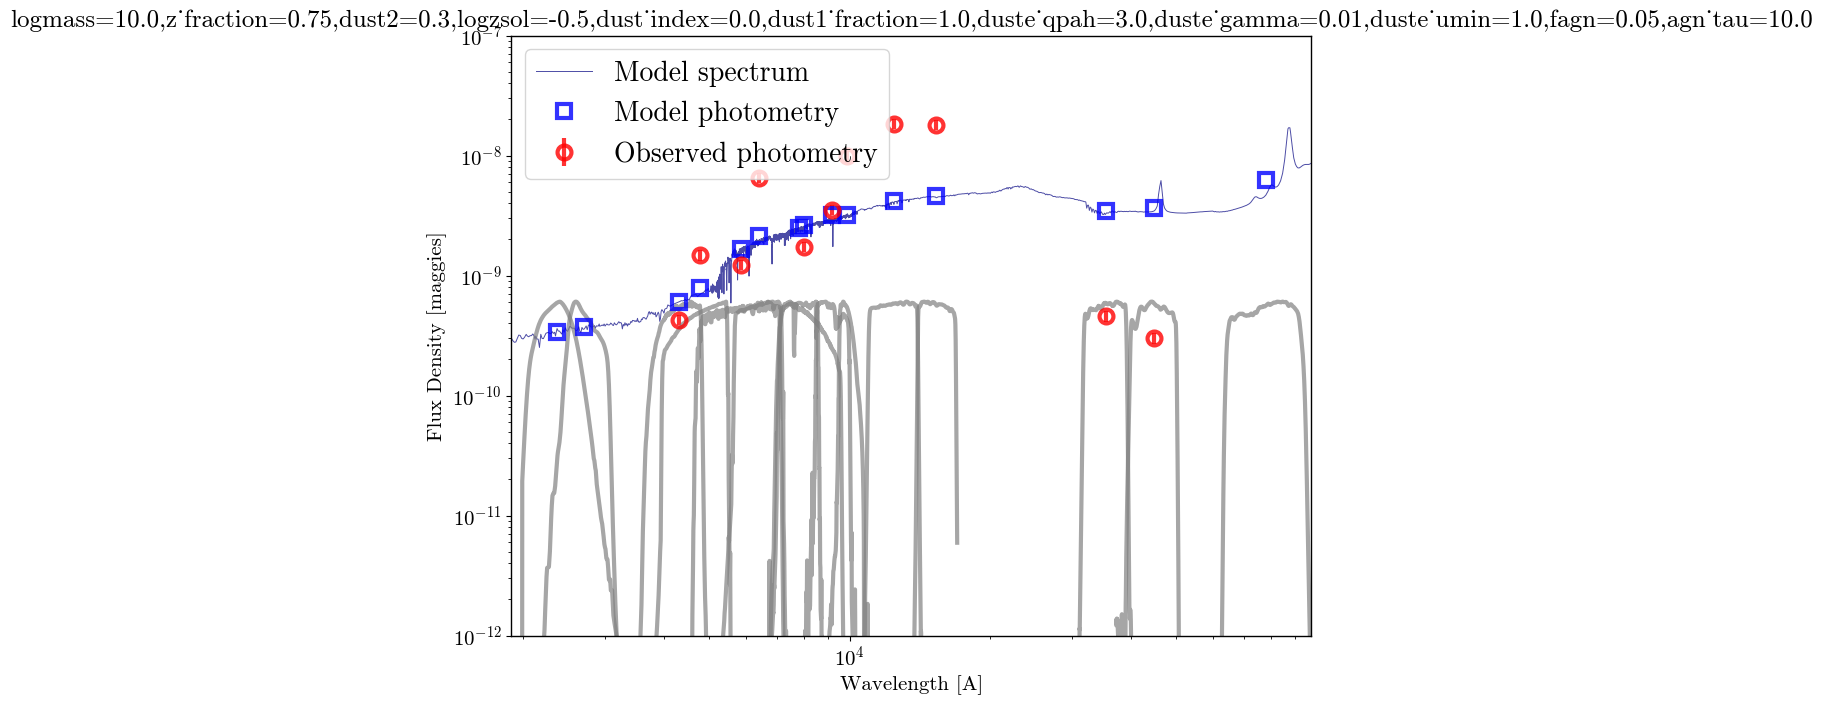

In [64]:
# Generate the model SED at the initial value of theta
theta = model.theta.copy()
initial_spec, initial_phot, initial_mfrac = model.sed(theta, obs=obs, sps=sps)
title_text = ','.join(["{}={}".format(p, model.params[p][0]) 
                       for p in model.free_params])

a = 1.0 + model.params.get('zred', 0.0) # cosmological redshifting
# photometric effective wavelengths
wphot = obs["phot_wave"]
# spectroscopic wavelengths
if obs["wavelength"] is None:
    # *restframe* spectral wavelengths, since obs["wavelength"] is None
    wspec = sps.wavelengths
    wspec *= a #redshift them
else:
    wspec = obs["wavelength"]

# establish bounds
xmin, xmax = np.min(wphot)*0.8, np.max(wphot)/0.8
temp = np.interp(np.linspace(xmin,xmax,10000), wspec, initial_spec)
ymin, ymax = temp.min()*0.8, temp.max()/0.4

fig, ax = pf.create_plot((8,6))

# plot model + data
ax.loglog(wspec, initial_spec, label='Model spectrum', 
       lw=0.7, color='navy', alpha=0.7)
ax.errorbar(wphot, initial_phot, label='Model photometry', 
         marker='s',markersize=10, alpha=0.8, ls='', lw=3,
         markerfacecolor='none', markeredgecolor='blue', 
         markeredgewidth=3)
ax.errorbar(wphot, obs['maggies'], yerr=obs['maggies_unc'], 
         label='Observed photometry',
         marker='o', markersize=10, alpha=0.8, ls='', lw=3,
         ecolor='red', markerfacecolor='none', markeredgecolor='red', 
         markeredgewidth=3)
ax.set_title(title_text)

mask2 = obs['mask']
# ax.plot(obs['wavelength'][mask2],obs['spectrum'][mask2],label='spectrum', alpha=0.3,zorder=-10)

# plot Filters
for f in obs['filters']:
    w, t = f.wavelength.copy(), f.transmission.copy()
    t = t / t.max()
    t = 10**(0.2*(np.log10(ymax/ymin)))*t * ymin
    ax.loglog(w, t, lw=3, color='gray', alpha=0.7)

# prettify
ax.set_xlabel('Wavelength [A]')
ax.set_ylabel('Flux Density [maggies]')
ax.set_xlim([xmin, xmax])
ax.set_ylim([1e-12, 1e-7])
ax.legend(loc='best', fontsize=20)


In [65]:
model

:::::::
<class 'prospect.models.sedmodel.SedModel'>

Free Parameters: (name: prior) 
-----------
  logmass: <class 'prospect.models.priors.TopHat'>(mini=5.0,maxi=13.0)
  z_fraction: <class 'prospect.models.priors.Beta'>(mini=0.0,maxi=1.0,alpha=[3 2 1],beta=[1 1 1])
  dust2: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=3.0)
  logzsol: <class 'prospect.models.priors.TopHat'>(mini=-1.98,maxi=0.19)
  dust_index: <class 'prospect.models.priors.TopHat'>(mini=-2.2,maxi=0.4)
  dust1_fraction: <class 'prospect.models.priors.ClippedNormal'>(mean=1.0,sigma=0.3,mini=0.0,maxi=2.0)
  duste_qpah: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=10.0)
  duste_gamma: <class 'prospect.models.priors.TopHat'>(mini=0.0,maxi=1.0)
  duste_umin: <class 'prospect.models.priors.TopHat'>(mini=0.1,maxi=25.0)
  fagn: <class 'prospect.models.priors.LogUniform'>(mini=0.000316228,maxi=3.0)
  agn_tau: <class 'prospect.models.priors.LogUniform'>(mini=5.0,maxi=150.0)

Fixed Parameters: (name: value [, depe